# Embeddings de Palabras con GloVe
Los **embeddings** son representaciones numéricas densas de palabras en un espacio vectorial. Cada palabra se transforma en un vector de números reales donde palabras con significado parecido tienden a quedar cerca.

A diferencia de una codificación one-hot (muy dispersa), los embeddings capturan relaciones semánticas y sintácticas. Por eso permiten operaciones como:
- similitud entre palabras con coseno,
- búsquedas de palabras cercanas,
- analogías del tipo: rey - hombre + mujer = reina.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

np.set_printoptions(precision=4, suppress=True)

## 1) Carga de embeddings
Usaremos el archivo original del notebook:
- glove.6B.100d.txt

### Descarga/ubicacion rapida
1. Descarga `glove.6B.zip` desde el sitio oficial de GloVe.
2. Descomprime el archivo zip.
3. Copia `glove.6B.100d.txt` en la carpeta `data/` del proyecto.
4. Ejecuta la siguiente celda para cargarlo.

In [2]:
# Archivo original del notebook
glove_path = Path("data/glove.6B/glove.6B.100d.txt")

def cargar_embeddings(path):
    embeddings = {}
    dim_esperada = None
    lineas_invalidas = 0

    with open(path, "r", encoding="utf-8") as f:
        for i, linea in enumerate(f):
            valores = linea.strip().split()
            if not valores:
                continue

            # Salta cabecera tipo "num_tokens dim" si existe (formato word2vec)
            if i == 0 and len(valores) == 2 and valores[0].isdigit() and valores[1].isdigit():
                dim_esperada = int(valores[1])
                continue

            palabra = valores[0]
            try:
                vector = np.asarray(valores[1:], dtype="float32")
            except ValueError:
                lineas_invalidas += 1
                continue

            if vector.size == 0:
                lineas_invalidas += 1
                continue

            if dim_esperada is None:
                dim_esperada = int(vector.size)

            if vector.size != dim_esperada:
                lineas_invalidas += 1
                continue

            embeddings[palabra] = vector

    return embeddings, dim_esperada, lineas_invalidas

if glove_path.exists():
    embeddings, dim, lineas_invalidas = cargar_embeddings(glove_path)
    if embeddings:
        print(f"Embeddings cargados: {len(embeddings):,} palabras | Dimension: {dim}")
        if lineas_invalidas > 0:
            print(f"Lineas omitidas por formato/dimension invalida: {lineas_invalidas:,}")
    else:
        print("Se encontro el archivo, pero no se pudieron leer vectores validos.")
else:
    embeddings = {}
    print(f"No se encontro el archivo: {glove_path}")

Embeddings cargados: 400,000 palabras | Dimension: 100


In [14]:
embeddings

{'the': array([-0.0382, -0.2449,  0.7281, -0.3996,  0.0832,  0.044 , -0.3914,
         0.3344, -0.5755,  0.0875,  0.2879, -0.0673,  0.3091, -0.2638,
        -0.1323, -0.2076,  0.334 , -0.3385, -0.3174, -0.4834,  0.1464,
        -0.373 ,  0.3458,  0.052 ,  0.4495, -0.4697,  0.0263, -0.5415,
        -0.1552, -0.1411, -0.0397,  0.2828,  0.1439,  0.2346, -0.3102,
         0.0862,  0.204 ,  0.5262,  0.1716, -0.0824, -0.7179, -0.4153,
         0.2033, -0.1276,  0.4137,  0.5519,  0.5791, -0.3348, -0.3656,
        -0.5486, -0.0629,  0.2658,  0.302 ,  0.9977, -0.8048, -3.0243,
         0.0125, -0.3694,  2.2167,  0.722 , -0.2498,  0.9214,  0.0345,
         0.4674,  1.1079, -0.1936, -0.0746,  0.2335, -0.0521, -0.2204,
         0.0572, -0.1581, -0.308 , -0.4162,  0.3797,  0.1501, -0.5321,
        -0.2055, -1.2526,  0.0716,  0.7056,  0.4974, -0.4206,  0.2615,
        -1.538 , -0.3022, -0.0734, -0.2831,  0.371 , -0.2522,  0.0162,
        -0.0171, -0.3898,  0.8742, -0.7257, -0.5106, -0.5203, -0.1459,

## 2) Similitud de coseno y palabras más similares
Implementamos funciones base para consultar el espacio vectorial de palabras.

In [4]:
def similitud_coseno(v1, v2, eps=1e-12):
    den = (np.linalg.norm(v1) * np.linalg.norm(v2)) + eps
    return float(np.dot(v1, v2) / den)

def palabras_mas_similares(palabra, embeddings_dict, top_n=10):
    palabra = palabra.lower()
    if palabra not in embeddings_dict:
        raise KeyError(f"'{palabra}' no esta en el vocabulario.")

    v_palabra = embeddings_dict[palabra]
    similitudes = []

    for p, v in embeddings_dict.items():
        if p == palabra:
            continue
        sim = similitud_coseno(v_palabra, v)
        similitudes.append((p, sim))

    similitudes.sort(key=lambda x: x[1], reverse=True)
    return similitudes[:top_n]

## 3) Analogías vectoriales
Usamos la idea: palabra1 - palabra2 + palabra3 = ?

In [9]:
def analogia(palabra1, palabra2, palabra3, embeddings_dict):
    p1, p2, p3 = palabra1.lower(), palabra2.lower(), palabra3.lower()

    for p in (p1, p2, p3):
        if p not in embeddings_dict:
            raise KeyError(f"'{p}' no esta en el vocabulario.")

    objetivo = embeddings_dict[p1] - embeddings_dict[p2] + embeddings_dict[p3]

    mejor_palabra = None
    max_sim = -1.0

    for p, v in embeddings_dict.items():
        if p in {p1, p2, p3}:
            continue
        sim = similitud_coseno(objetivo, v)
        if sim > max_sim:
            max_sim = sim
            mejor_palabra = p

    return mejor_palabra, max_sim

## 4) Visualización de palabras
Proyectamos los vectores a 2D con PCA o t-SNE para inspección visual.

In [5]:
def graficar_embeddings(lista_palabras, embeddings_dict, metodo="pca", random_state=42):
    faltantes = [p for p in lista_palabras if p.lower() not in embeddings_dict]
    if faltantes:
        raise KeyError(f"Palabras no encontradas: {faltantes}")

    palabras = [p.lower() for p in lista_palabras]
    vectores = np.array([embeddings_dict[p] for p in palabras])

    if metodo.lower() == "pca":
        modelo = PCA(n_components=2)
    elif metodo.lower() == "tsne":
        perplexity = min(5, len(palabras) - 1)
        modelo = TSNE(n_components=2, random_state=random_state, perplexity=perplexity)
    else:
        raise ValueError("metodo debe ser 'pca' o 'tsne'")

    resultado = modelo.fit_transform(vectores)

    plt.figure(figsize=(10, 8))
    plt.scatter(resultado[:, 0], resultado[:, 1])
    for i, palabra in enumerate(palabras):
        plt.annotate(palabra, (resultado[i, 0], resultado[i, 1]))
    plt.title(f"Visualizacion de embeddings ({metodo.upper()})")
    plt.xlabel("Componente 1")
    plt.ylabel("Componente 2")
    plt.grid(alpha=0.2)
    plt.show()

## 5) Ejemplos de uso
Si cargaste GloVe correctamente, ejecuta estas celdas para explorar resultados.

In [7]:
if embeddings:
    palabra_consulta = "cat" if "cat" in embeddings else next(iter(embeddings.keys()))
    print(f"Palabra de consulta: {palabra_consulta}")
    for palabra, score in palabras_mas_similares(palabra_consulta, embeddings, top_n=10):
        print(f"{palabra:20s} {score:.4f}")
else:
    print("No hay embeddings cargados.")

Palabra de consulta: cat
dog                  0.8798
rabbit               0.7424
cats                 0.7323
monkey               0.7289
pet                  0.7190
dogs                 0.7164
mouse                0.6915
puppy                0.6800
rat                  0.6641
spider               0.6501


In [10]:
if embeddings and all(w in embeddings for w in ["king", "man", "woman"]):
    pred, score = analogia("king", "man", "woman", embeddings)
    print(f"king - man + woman = {pred} (sim={score:.4f})")
else:
    print("No se pudo ejecutar la analogia de ejemplo (faltan palabras o embeddings).")

king - man + woman = queen (sim=0.7834)


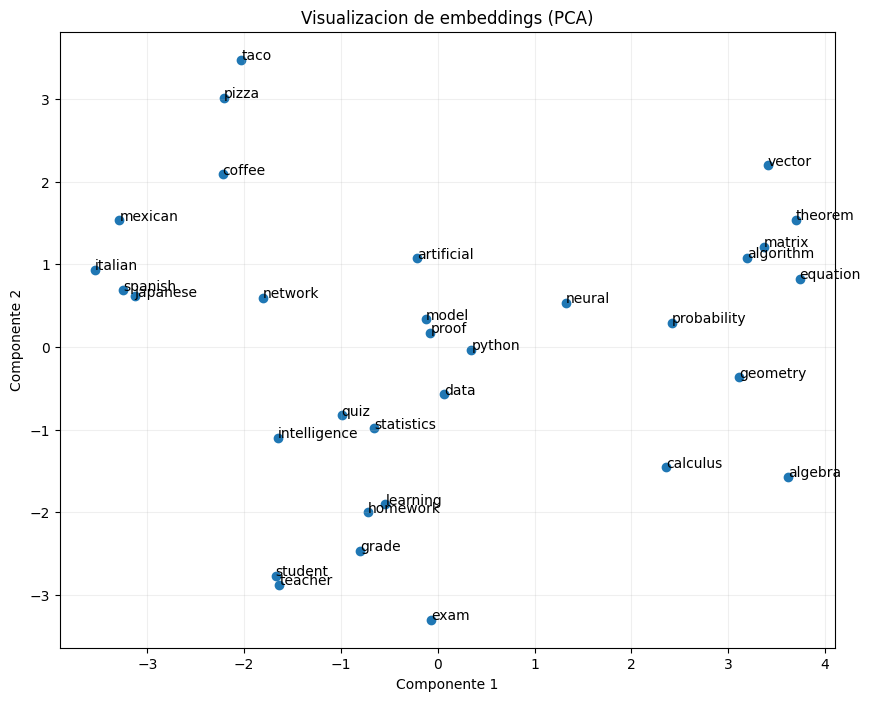

In [13]:
palabras_plot = [
    "student", "teacher", "homework", "exam", "quiz", "grade",
    "algebra", "geometry", "calculus", "matrix", "vector", "equation",
    "probability", "statistics", "theorem", "proof",
    "intelligence", "artificial", "neural", "network", "learning", "model",
    "python", "data", "algorithm", "coffee", "pizza", "mexican", "taco", "japanese",'italian', 'spanish'
]

if embeddings and all(w in embeddings for w in palabras_plot):
    graficar_embeddings(palabras_plot, embeddings, metodo="pca")
else:
    faltantes = [w for w in palabras_plot if w not in embeddings]
    print("No se pudo generar la grafica de ejemplo (faltan palabras o embeddings).")
    print("Palabras faltantes:", faltantes)

## Conclusiones
- Los embeddings representan palabras como vectores densos.
- La similitud de coseno permite medir cercanía semántica.
- Las analogías emergen por relaciones lineales en el espacio vectorial.
- Para mejores resultados, usa un vocabulario grande y dimensiones más altas (por ejemplo 200 o 300).